https://colab.research.google.com/drive/1r2WASKpZ6sZ0j5FH6a2wuOBW5uQCMwxQ?usp=sharing

# **Sales Forecasting Case Study**

## Objective

The objective of this notebook is to forecast future sales using different forecasting techniques. I will first explore and preprocess the dataset, then build multiple forecasting models including Linear Regression, ARIMA and Prophet. Finally, I will compare their performance using MAE, RMSE and R² score, and analyze why certain models perform better or worse.

**Forecasting = Regression + Time**

Forecasting predicts too just like regression but the time becomes important.

**Import and explore the dataset :**

In [1]:
import pandas as pd

df = pd.read_csv('/content/drive/MyDrive/Data Science Course/DATASETS/dailysales.csv')

df

,date,sales
0,01-Jan-18,477.0
1,02-Jan-18,365.0
2,03-Jan-18,442.0
3,04-Jan-18,490.0
4,05-Jan-18,396.0
...,...,...
699,27-Dec-19,133.0
700,28-Dec-19,214.1
701,29-Dec-19,85.5
702,30-Dec-19,182.9


In [2]:
df.shape

(704, 2)

In [3]:
df.columns

Index(['date', 'sales'], dtype='object')

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 704 entries, 0 to 703
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   date    704 non-null    object 
 1   sales   704 non-null    float64
dtypes: float64(1), object(1)
memory usage: 11.1+ KB


#### Dataset Overview

Initially I checked the structure of the dataset to understand the available features and identify any missing values before building forecasting models.

Checking missing values :

In [5]:
df.isnull().sum()

,0
date,0
sales,0


No missing values found.

### **Convert date columns into appropriate datetime format:**

In [6]:
df.head()

,date,sales
0,01-Jan-18,477.0
1,02-Jan-18,365.0
2,03-Jan-18,442.0
3,04-Jan-18,490.0
4,05-Jan-18,396.0


Currently pandas treats this as text. ML can't understand dates as strings.

In [11]:
df["date"] = pd.to_datetime(df["date"])


print(df.dtypes)

date     datetime64[ns]
sales           float64
dtype: object


In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 704 entries, 0 to 703
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   date    704 non-null    datetime64[ns]
 1   sales   704 non-null    float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 11.1 KB


In [13]:
#Sort by Date
df = df.sort_values("date")

df.head()

,date,sales
0,2018-01-01,477.0
1,2018-01-02,365.0
2,2018-01-03,442.0
3,2018-01-04,490.0
4,2018-01-05,396.0


In [15]:
#setting date as index

df.set_index("date", inplace=True)

df.head()

,sales
date,
2018-01-01,477.0
2018-01-02,365.0
2018-01-03,442.0
2018-01-04,490.0
2018-01-05,396.0


In [18]:
print(df.index.min())
print(df.index.max())

2018-01-01 00:00:00
2019-12-31 00:00:00


### Observations

- The Date column was successfully converted into datetime format.
- The dataset was sorted chronologically to preserve the time order.
- The Date column was set as the index, making it suitable for time series analysis.
- No duplicate records were found.
- No missing values were present in the dataset.
- The cleaned dataset is now ready for exploratory analysis and forecasting.

## **Exploratory Data Analysis :**

Line Plot :

In [20]:
import matplotlib.pyplot as plt

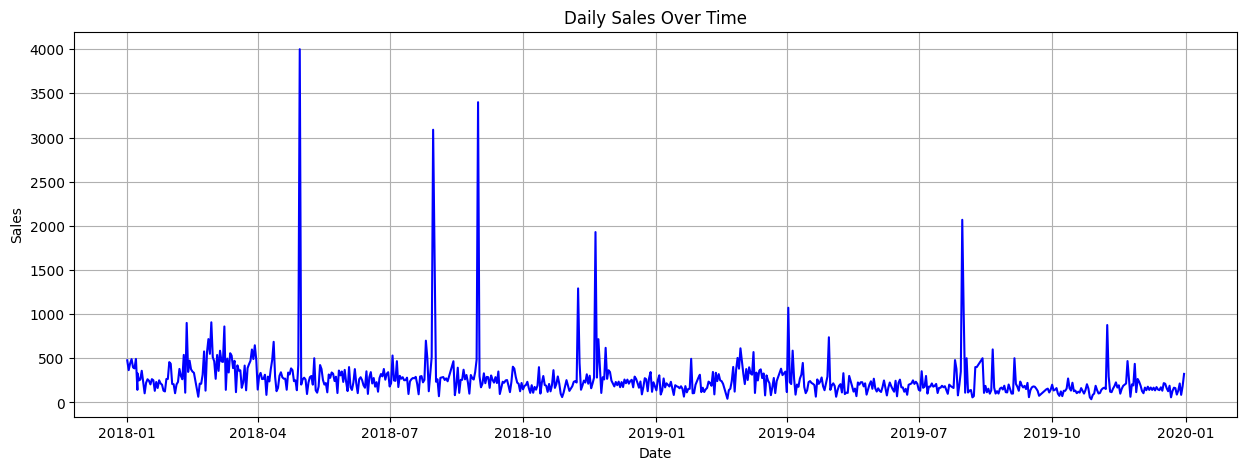

In [21]:
plt.figure(figsize=(15,5))

plt.plot(df.index, df["sales"], color="blue")

plt.title("Daily Sales Over Time")
plt.xlabel("Date")
plt.ylabel("Sales")

plt.grid(True)

plt.show()

### Observations

After plotting the daily sales, I noticed that the sales fluctuate considerably throughout the observed period. There are several sudden spikes where the sales increase far above the normal daily range, which may represent promotional events, holidays or other exceptional business activities.

I do not observe a strong long-term increasing or decreasing trend in the data. Additionally, no obvious seasonal pattern is visible from the line plot alone. Further analysis using rolling statistics and stationarity tests will help confirm the characteristics of the time series.

Histogram :

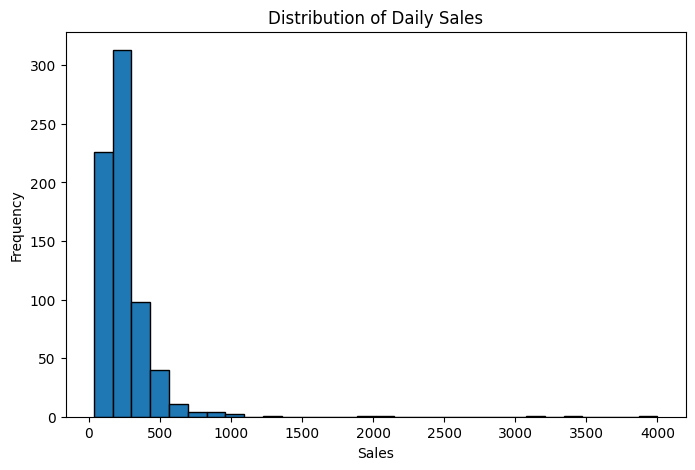

In [22]:
plt.figure(figsize=(8,5))

plt.hist(df["sales"], bins=30, edgecolor="black")

plt.title("Distribution of Daily Sales")
plt.xlabel("Sales")
plt.ylabel("Frequency")

plt.show()

### Observation

The histogram shows that most daily sales are concentrated within a relatively low range. However, a small number of observations have exceptionally high sales values, resulting in a right-skewed distribution. These extreme values may represent special events such as promotional campaigns or festive sales.

Boxplot :

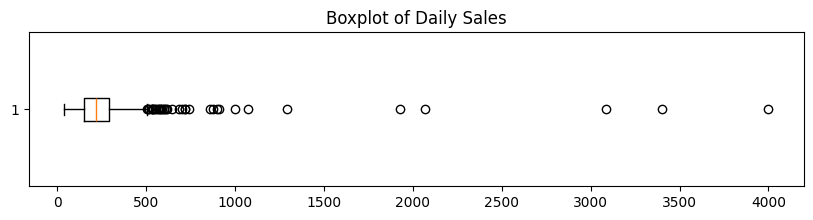

In [23]:
plt.figure(figsize=(10,2))

plt.boxplot(df["sales"], vert=False)

plt.title("Boxplot of Daily Sales")

plt.show()

### Observation

The boxplot confirms the presence of several outliers in the dataset. These unusually high sales values indicate that certain days experienced much larger sales than normal. Such outliers can increase forecasting errors and make it more difficult for models to accurately predict future sales.

Rolling Mean & Rolling Standard Deviation :

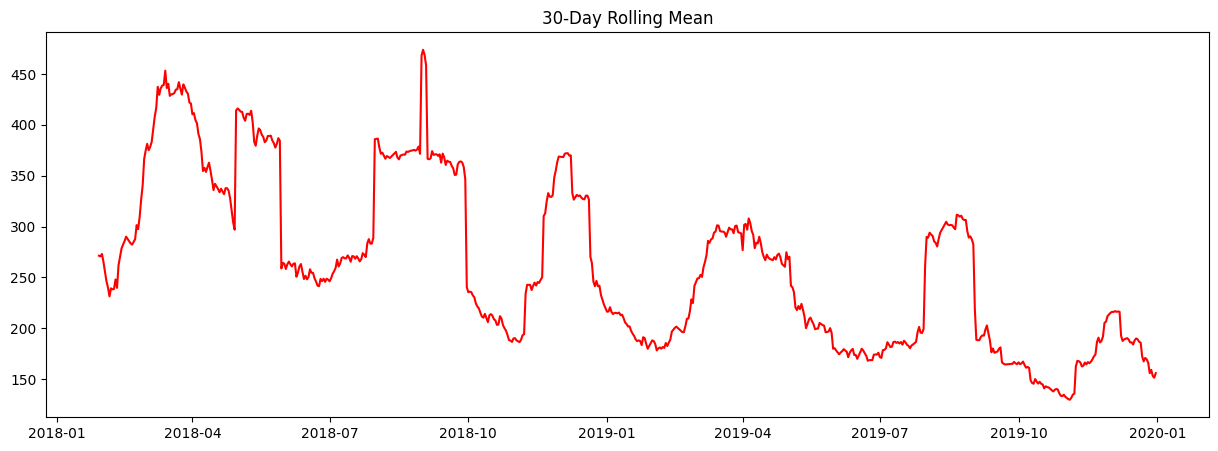

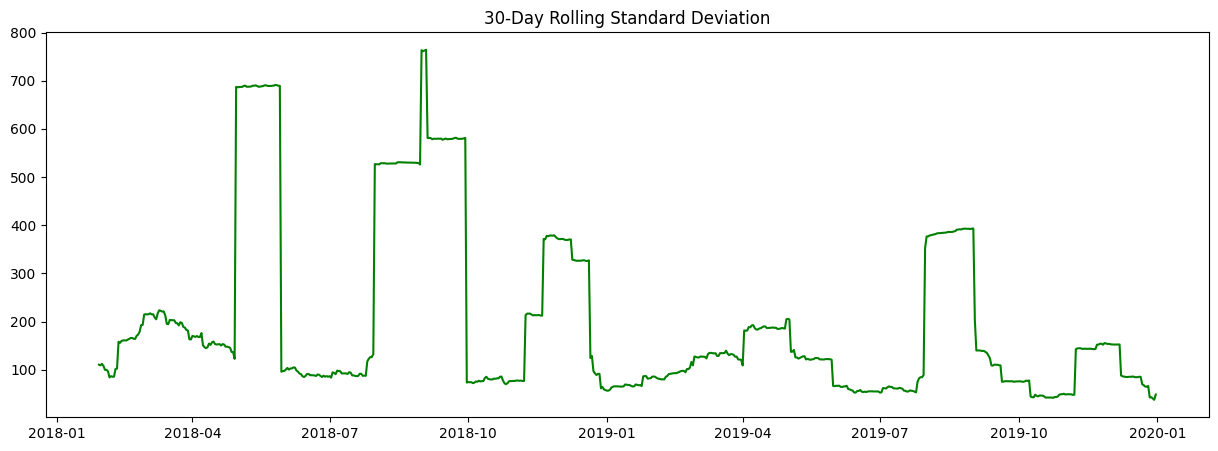

In [25]:
rolling_mean = df["sales"].rolling(window=30).mean()
rolling_std = df["sales"].rolling(window=30).std()

plt.figure(figsize=(15,5))
plt.plot(rolling_mean, color='red')
plt.title("30-Day Rolling Mean")
plt.show()

plt.figure(figsize=(15,5))
plt.plot(rolling_std, color='green')
plt.title("30-Day Rolling Standard Deviation")
plt.show()

## **Stationarity Analysis :**

ADF test :

In [26]:
from statsmodels.tsa.stattools import adfuller

In [27]:
result = adfuller(df["sales"])

print("ADF Statistic :", result[0])
print("p-value       :", result[1])
print("Critical Values:")

for key, value in result[4].items():
    print(f"{key}: {value}")

ADF Statistic : -23.01131324012155
p-value       : 0.0
Critical Values:
1%: -3.4396861854831964
5%: -2.865660062273053
10%: -2.5689640195342456


### Observation

The ADF test gave a p-value of **0.0**, which is less than **0.05**.

This means the sales data is already stationary.

So, I don't need to apply differencing before using the ARIMA model.

Therefore, **d = 0**.

PACF Plot:

<Figure size 1000x500 with 0 Axes>

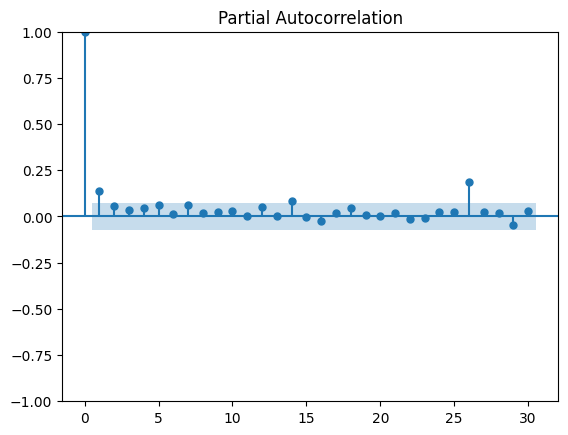

In [28]:
from statsmodels.graphics.tsaplots import plot_pacf

plt.figure(figsize=(10,5))
plot_pacf(df["sales"], lags=30)
plt.show()

ACF Plot :

<Figure size 1000x500 with 0 Axes>

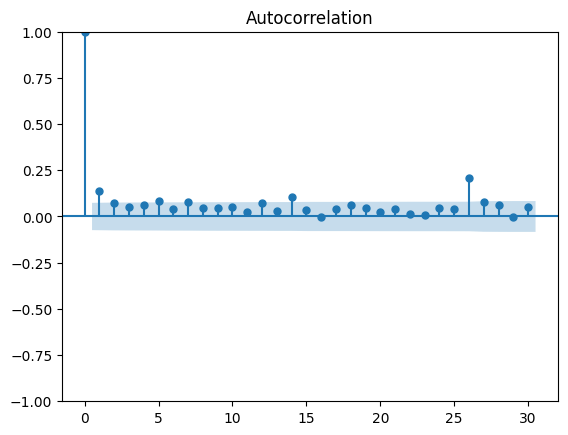

In [29]:
from statsmodels.graphics.tsaplots import plot_acf

plt.figure(figsize=(10,5))
plot_acf(df["sales"], lags=30)
plt.show()

### Observation

From the PACF plot, only Lag 1 is significant, so I selected **p = 1**.

From the ACF plot, only Lag 1 is significant, so I selected **q = 1**.

Since the data is already stationary, **d = 0**.

Therefore, I selected **ARIMA(1,0,1)** for forecasting.

### **Extract relevant features (month, day, year, etc.):**

In [34]:
print(df.columns)

Index(['sales'], dtype='object')


In [35]:
df['Year'] = df.index.year
df['Month'] = df.index.month
df['Day'] = df.index.day
df['DayOfWeek'] = df.index.dayofweek

In [36]:
df.head()

,sales,Year,Month,Day,DayOfWeek
date,,,,,
2018-01-01,477.0,2018,1,1,0
2018-01-02,365.0,2018,1,2,1
2018-01-03,442.0,2018,1,3,2
2018-01-04,490.0,2018,1,4,3
2018-01-05,396.0,2018,1,5,4


#### Feature Extraction

The date column was converted into datetime format and important time-based features were extracted.

The following features were created:

- Year
- Month
- Day
- DayOfWeek

These features help capture temporal patterns in sales data and can be used as inputs for forecasting models.

In [37]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 704 entries, 2018-01-01 to 2019-12-31
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   sales      704 non-null    float64
 1   Year       704 non-null    int32  
 2   Month      704 non-null    int32  
 3   Day        704 non-null    int32  
 4   DayOfWeek  704 non-null    int32  
dtypes: float64(1), int32(4)
memory usage: 22.0 KB


## **Linear Regression :**

### **Train-Test Split:**

In [38]:
X = df[['Year', 'Month', 'Day', 'DayOfWeek']]
y = df['sales']

In [39]:
split_index = int(len(df) * 0.8)

X_train = X[:split_index]
X_test = X[split_index:]

y_train = y[:split_index]
y_test = y[split_index:]

print("Training Records:", len(X_train))
print("Testing Records:", len(X_test))

Training Records: 563
Testing Records: 141


In [40]:
#Linear Regression

from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

In [41]:
y_pred = model.predict(X_test)

In [42]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))

r2 = r2_score(y_test, y_pred)

print("MAE :", mae)
print("RMSE:", rmse)
print("R² :", r2)

MAE : 85.01797911037768
RMSE: 122.9607964426481
R² : -0.38085086022277737


### Linear Regression Results

MAE  = 85.02

RMSE = 122.96

R²   = -0.381

### Observation

The model was able to predict sales, but the R² score is negative. This means the model performed worse than simply predicting the average sales value.

Using only Year, Month, Day and DayOfWeek was not enough to capture the daily sales pattern, especially because the dataset contains many sudden spikes and fluctuations.

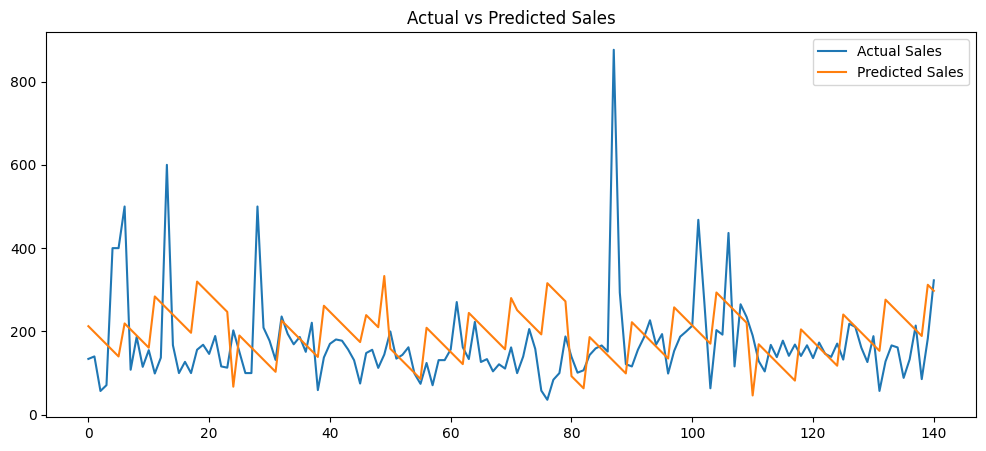

In [43]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(y_test.values, label='Actual Sales')
plt.plot(y_pred, label='Predicted Sales')
plt.legend()
plt.title('Actual vs Predicted Sales')
plt.show()

#### Actual vs Predicted Sales Analysis

The predicted sales values follow the overall sales pattern but fail to capture several sharp increases and decreases in actual sales. The model produces smoother predictions and struggles to identify sudden sales spikes.

This suggests that the date-based features alone are not sufficient to explain all variations in sales, leading to lower forecasting accuracy.

Check if the series is stationary :

## **ARIMA Model:**

ARIMA is a forecasting model that uses previous sales values to predict future sales. Before training the model, I checked whether the data was stationary using the ADF test and selected the ARIMA parameters using the ACF and PACF plots.

In [44]:
# Train-Test Split for ARIMA

split_index = int(len(df) * 0.8)

train = df["sales"][:split_index]
test = df["sales"][split_index:]

print("Training Records:", len(train))
print("Testing Records :", len(test))

Training Records: 563
Testing Records : 141


In [45]:
from statsmodels.tsa.arima.model import ARIMA

model = ARIMA(train, order=(1,0,1))

model_fit = model.fit()

print(model_fit.summary())

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:                  sales   No. Observations:                  563
Model:                 ARIMA(1, 0, 1)   Log Likelihood               -3996.030
Date:                Fri, 26 Jun 2026   AIC                           8000.060
Time:                        16:34:39   BIC                           8017.393
Sample:                             0   HQIC                          8006.827
                                - 563                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const        284.3954     49.155      5.786      0.000     188.053     380.737
ar.L1          0.9344      0.077     12.133      0.000       0.783       1.085
ma.L1         -0.8848      0.094     -9.393      0.0

### Observation

The ARIMA(1,0,1) model was successfully trained. Both the AR and MA terms have very small p-values (less than 0.05), indicating that they contribute significantly to the model.

In [46]:
# Forecast for test data

forecast = model_fit.forecast(steps=len(test))

forecast.head()

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


,predicted_mean
563,343.288575
564,339.423216
565,335.811554
566,332.436937
567,329.283808


In [47]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(test, forecast)
rmse = np.sqrt(mean_squared_error(test, forecast))
r2 = r2_score(test, forecast)

print("MAE :", mae)
print("RMSE:", rmse)
print("R²  :", r2)

MAE : 144.68987456579293
RMSE: 158.41637406500777
R²  : -1.2919945315221524


### ARIMA Results

MAE  = 144.69

RMSE = 158.42

R²   = -1.292

### Observation

The ARIMA model produced a negative R² score, which means it performed worse than predicting the average sales value. The model was not able to capture the sudden changes in daily sales accurately.

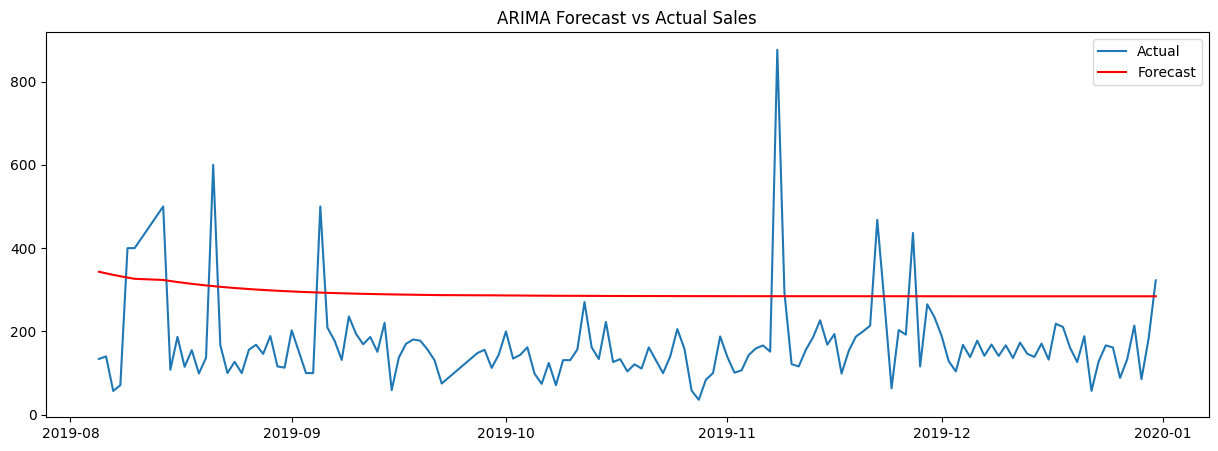

In [48]:
plt.figure(figsize=(15,5))

plt.plot(test.index, test, label="Actual")
plt.plot(test.index, forecast, label="Forecast", color="red")

plt.title("ARIMA Forecast vs Actual Sales")

plt.legend()

plt.show()

### Observation

The forecast line is much smoother than the actual sales. It follows the general average of the data but misses the sudden spikes and drops.

Because of this, the prediction error becomes large, resulting in a negative R² score.

#### Model Comparison

Two forecasting approaches were evaluated: Linear Regression and ARIMA.

| Model | MAE | RMSE | R² Score |
|--------|--------|--------|--------|
| Linear Regression | 85.02 | 122.96 | -0.38 |
| ARIMA | 144.69 | 158.42 | -1.29 |

### Observation

The Linear Regression model outperformed the ARIMA model across all evaluation metrics. ARIMA produced higher prediction errors and a lower R² score, indicating weaker forecasting performance on this dataset.

This may be due to the presence of irregular sales spikes and fluctuations that could not be effectively captured by the ARIMA model.

Residual Plot:

In [70]:
forecast_series = pd.Series(
    forecast.to_numpy(),   # or forecast.values
    index=test.index
)

residuals = pd.Series(
    test.values - forecast.values,
    index=test.index
)

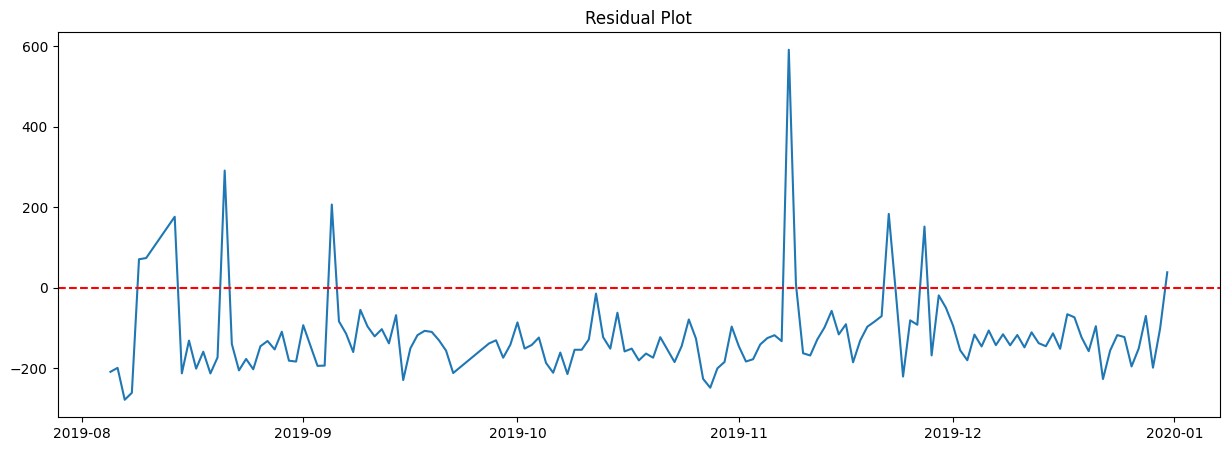

In [71]:
plt.figure(figsize=(15,5))
plt.plot(residuals)

plt.axhline(0, color='red', linestyle='--')

plt.title("Residual Plot")

plt.show()

### Observation

Most residuals are below zero, with a few very large positive spikes. This shows that the model could not predict some sudden changes in sales accurately.

Residual Histogram :

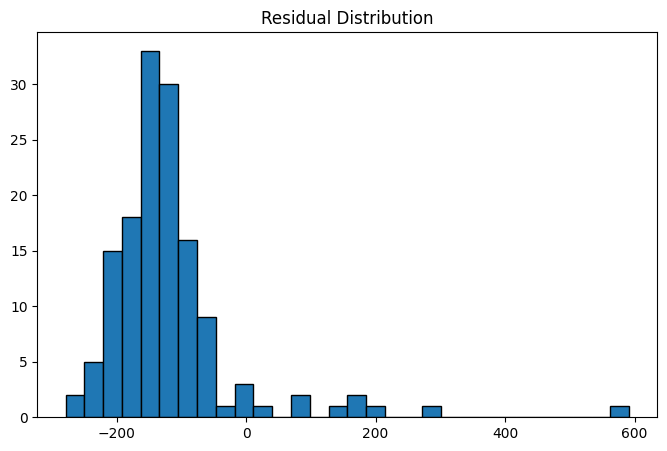

In [74]:
plt.figure(figsize=(8,5))

plt.hist(residuals, bins=30, edgecolor='black')

plt.title("Residual Distribution")

plt.show()

### Observation

The residuals are not centered around zero and the distribution is slightly skewed. This suggests that the prediction errors are not completely random.

Residual ACF :

<Figure size 1000x500 with 0 Axes>

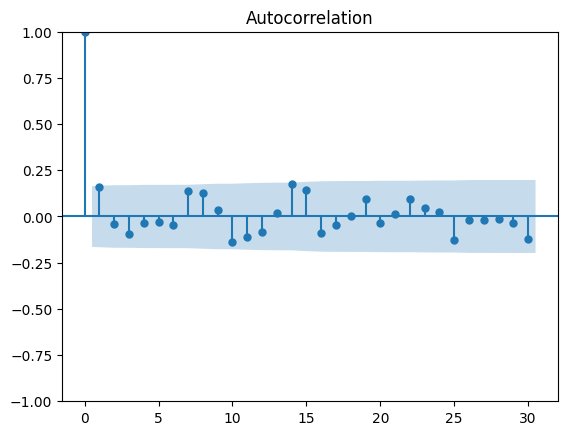

In [75]:
from statsmodels.graphics.tsaplots import plot_acf

plt.figure(figsize=(10,5))
plot_acf(residuals, lags=30)
plt.show()

### Observation

Most of the residual autocorrelation values are inside the confidence interval. This means the residuals do not show a strong remaining time pattern.

However, the model still produced large prediction errors because it could not capture the sudden spikes in sales.

## **Prophet Model:**

Prophet is a forecasting model developed for time series data. It can automatically capture trend and seasonality without manually selecting parameters like ARIMA.

In [76]:
prophet_df = df.reset_index()[["date", "sales"]]

prophet_df.columns = ["ds", "y"]

prophet_df.head()

,ds,y
0,2018-01-01,477.0
1,2018-01-02,365.0
2,2018-01-03,442.0
3,2018-01-04,490.0
4,2018-01-05,396.0


In [77]:
split_index = int(len(prophet_df) * 0.8)

train = prophet_df.iloc[:split_index]

test = prophet_df.iloc[split_index:]

In [78]:
from prophet import Prophet

model = Prophet()

model.fit(train)

INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


In [79]:
future = model.make_future_dataframe(
    periods=len(test),
    freq="D"
)

In [80]:
forecast = model.predict(future)

In [81]:
y_pred = forecast["yhat"].tail(len(test)).values

In [82]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
import numpy as np

mae = mean_absolute_error(test['y'], y_pred)
rmse = np.sqrt(mean_squared_error(test['y'], y_pred))
r2 = r2_score(test['y'], y_pred)

print("MAE :", mae)
print("RMSE:", rmse)
print("R² :", r2)

MAE : 83.15942227425454
RMSE: 117.54873607615096
R² : -0.26197097802125957


### Prophet Results

MAE  = 83.16

RMSE = 117.55

R²   = -0.262

### Observation

Among the three models, Prophet gave the lowest MAE and RMSE. However, the R² score is still negative, which means it could not predict the sales accurately.

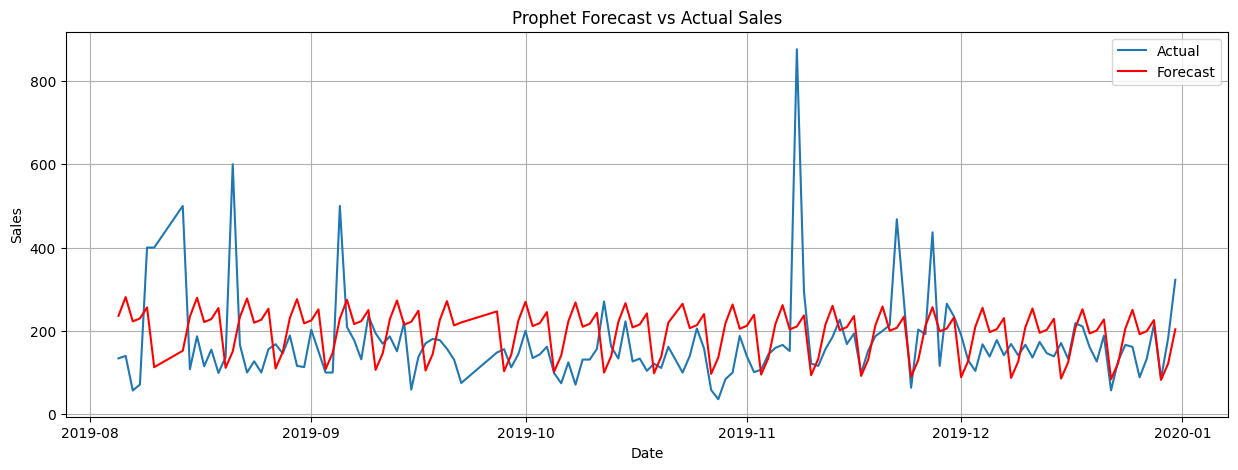

In [84]:
plt.figure(figsize=(15,5))

plt.plot(test["ds"], test["y"], label="Actual")
plt.plot(test["ds"], y_pred, label="Forecast", color="red")

plt.title("Prophet Forecast vs Actual Sales")

plt.xlabel("Date")
plt.ylabel("Sales")

plt.legend()

plt.grid(True)

plt.show()

### Observation

The Prophet model follows the overall trend better than ARIMA. However, it still misses the sudden spikes in sales. Because of this, the prediction errors are lower than ARIMA but the R² score is still negative.

Among the three models, Prophet produced the lowest MAE and RMSE. However, its R² score is still negative, which means the forecasting performance is not satisfactory.

# **Comparision :**

In [86]:
comparison = pd.DataFrame({
    "Model": ["Linear Regression", "ARIMA", "Prophet"],
    "MAE": [85.02, 144.69, 83.16],
    "RMSE": [122.96, 158.42, 117.55],
    "R² Score": [-0.381, -1.292, -0.262]
})

comparison

,Model,MAE,RMSE,R² Score
0,Linear Regression,85.02,122.96,-0.381
1,ARIMA,144.69,158.42,-1.292
2,Prophet,83.16,117.55,-0.262


In [87]:
best_model = comparison.loc[comparison["RMSE"].idxmin()]

print("Model with Lowest RMSE")
print(best_model)

Model with Lowest RMSE
Model       Prophet
MAE           83.16
RMSE         117.55
R² Score     -0.262
Name: 2, dtype: object


## Findings and Analysis

# Why did the models perform poorly?

All three models produced a negative R² score, which means none of them performed better than predicting the average sales.

Possible reasons are:

- The sales data contains many sudden spikes that are difficult to predict.
- Only the sales values and date information were available. Other important factors like holidays, promotions or marketing campaigns were not included.
- Linear Regression could not capture the time-based pattern effectively.
- ARIMA assumes a regular time pattern, but the sales changed suddenly on many days.
- Prophet followed the overall trend but also missed the sudden spikes.

These results show that selecting a model is not enough. Understanding the data and its limitations is equally important.

# Conclusion

In this assignment, I implemented three forecasting models: Linear Regression, ARIMA and Prophet.

Among them, Prophet achieved the lowest MAE and RMSE, while ARIMA produced the highest prediction error.

However, all three models had a negative R² score, showing that none of them could predict the sales accurately.

This assignment helped me understand how to analyze a time series dataset, check stationarity using the ADF test, select ARIMA parameters using ACF and PACF, evaluate forecasting models and understand why a model may fail instead of only comparing accuracy values.